# Phase 2 — Reconstruct from Real-World Strip Scans
### Works with any filenames — joker.jpg, ball.jpg, anything

**How to use this notebook**

1. Put all your scanned strip images in one folder
2. Set `STRIPS_DIR` in the Configuration cell
3. Run all cells top to bottom
4. If any strips are in the wrong position, edit `SWAPS` and re-run from Step 6

---

**There is no Phase 1. There is no original image. Filenames do not matter.**

The algorithm reads pixel content only — it does not look at filenames at all.  
You will be assigned an **index number** `[0]`, `[1]`, `[2]` … for each file.  
Use those index numbers when doing manual swaps.

```
your folder
┌──────────────────────────────┐      index assigned
│  joker.jpg                   │  →  [0]
│  ball.jpg                    │  →  [1]
│  sunset.png                  │  →  [2]
│  anything_at_all.jpeg        │  →  [3]
└──────────────────────────────┘
         ↓
  algorithm reads pixels → finds correct order
         ↓
  reconstructed_clean.png
```

---
## Setup

In [15]:
import numpy as np
from PIL import Image
from scipy.signal import correlate
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import glob, os

plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#1a1a1a',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'axes.edgecolor':   '#444444',
})
print('Libraries loaded.')

Libraries loaded.


---
## Configuration

### Option A — Point at a folder (files sorted alphabetically)
Leave `FILE_ORDER = []` and set `STRIPS_DIR`.

### Option B — List files in your own order
Set `FILE_ORDER` to a list of full paths. This overrides alphabetical sorting  
and lets you control which file gets index `[0]`, `[1]`, etc.

```python
# Example Option B:
FILE_ORDER = [
    'my_strips/joker.jpg',
    'my_strips/ball.jpg',
    'my_strips/sunset.png',
]
```

In [16]:
# ── Option A: folder path (leave FILE_ORDER empty) ────────────────
STRIPS_DIR = 'strips'      # ← your folder

FILE_ORDER = [
    r"C:\Data_Learnings\CV_engineer\Shread\daku.jpg",
    r"C:\Data_Learnings\CV_engineer\Shread\uber.jpg",
    r"C:\Data_Learnings\CV_engineer\Shread\holaa.jpg",
    r"C:\Data_Learnings\CV_engineer\Shread\ola.jpg"
]
# ── Accepted image formats ────────────────────────────────────────
EXTENSIONS = ['.jpg', '.jpeg', '.png', '.tif', '.tiff']

# ── Algorithm settings ───────────────────────────────────────────
BEAM_WIDTH = 5     # increase to 8–10 for more strips or harder images
EDGE_WIDTH = 15     # 0 = auto (6 for white paper, 20 for textured/camera)

# ── Output filenames ─────────────────────────────────────────────
CLEAN_PATH  = 'reconstructed_clean.png'
RESULT_PATH = 'reconstructed_result.png' 

---
## Step 1 — Discover files and assign index numbers

**Index numbers are permanent for this session.**  
A big reference table is printed so you can always look up which file is `[0]`, `[1]` etc.
Use these numbers in the `SWAPS` cell if you need to correct the algorithm.

In [17]:
def discover_files(strips_dir, file_order, extensions):
    """
    Return ordered list of image file paths.

    If file_order is given → use that exact list (Option B).
    Otherwise → find all image files in strips_dir, sort alphabetically (Option A).

    Files can have ANY name — joker.jpg, ball.png, xyz_001.jpeg, anything.
    The filename is never read by the algorithm — only pixel content matters.
    """
    if file_order:
        # Option B: user-supplied list
        missing = [p for p in file_order if not os.path.exists(p)]
        if missing:
            raise FileNotFoundError(f"Files not found: {missing}")
        return list(file_order)

    # Option A: auto-discover
    found = []
    for ext in extensions:
        found += glob.glob(os.path.join(strips_dir, f'*{ext}'))
        found += glob.glob(os.path.join(strips_dir, f'*{ext.upper()}'))

    unique = sorted(set(found), key=lambda p: os.path.basename(p).lower())

    if not unique:
        raise FileNotFoundError(
            f"No image files found in '{strips_dir}'.\n"
            f"Accepted: {extensions}\n"
            f"Or use FILE_ORDER to list files explicitly."
        )
    return unique


def load_strip(path):
    """Load one image → 2D grayscale uint8 NumPy array."""
    return np.array(Image.open(path).convert('L'), dtype=np.uint8)


# ── Discover and load ─────────────────────────────────────────────
paths  = discover_files(STRIPS_DIR, FILE_ORDER, EXTENSIONS)
strips = [load_strip(p) for p in paths]
N      = len(strips)

mode = 'user-supplied order (Option B)' if FILE_ORDER else 'alphabetical order (Option A)'
print(f'Found {N} files  [{mode}]')
print()

# ── INDEX REFERENCE TABLE ─────────────────────────────────────────
# Print this prominently — user needs it for SWAPS
print('=' * 60)
print('  INDEX → FILENAME REFERENCE')
print('  Use these index numbers in the SWAPS cell')
print('=' * 60)
for i, (p, s) in enumerate(zip(paths, strips)):
    ink  = round(np.sum(s < 128) / s.size * 100, 1)
    size = round(os.path.getsize(p) / 1024)
    print(f'  [{i}]  {os.path.basename(p):<35}  '
          f'{s.shape[1]}×{s.shape[0]}px  '
          f'ink={ink}%  {size}KB')
print('=' * 60) 

Found 4 files  [user-supplied order (Option B)]

  INDEX → FILENAME REFERENCE
  Use these index numbers in the SWAPS cell
  [0]  daku.jpg                             440×3064px  ink=16.9%  218KB
  [1]  uber.jpg                             640×3064px  ink=12.7%  242KB
  [2]  holaa.jpg                            304×3064px  ink=15.5%  147KB
  [3]  ola.jpg                              560×3064px  ink=9.4%  188KB


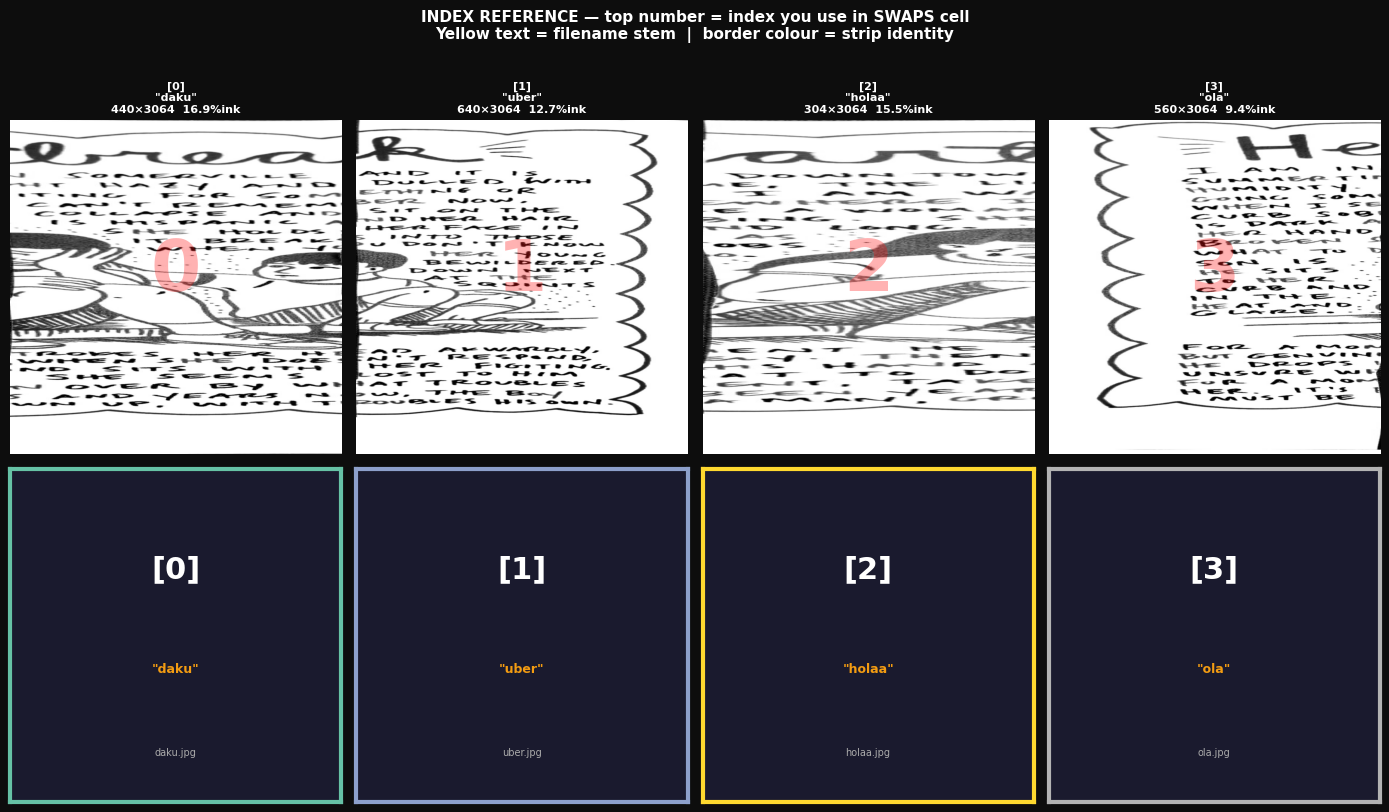

Keep this cell output visible — you will need the index numbers in Step 6.


In [18]:
# Visual index card for each strip
# Large index number + filename so you can identify strips at a glance
fig, axes = plt.subplots(2, N, figsize=(3.5 * N, 8))
if N == 1:
    axes = axes.reshape(2, 1)

COLORS = plt.cm.Set2(np.linspace(0, 1, N))

for i, (s, p) in enumerate(zip(strips, paths)):
    fname = os.path.basename(p)
    stem  = os.path.splitext(fname)[0]   # filename without extension
    ink   = round(np.sum(s < 128) / s.size * 100, 1)

    # top: strip image with large index overlay
    axes[0, i].imshow(s, cmap='gray', aspect='auto', vmin=0, vmax=255)
    for sp in axes[0, i].spines.values():
        sp.set_edgecolor(COLORS[i]); sp.set_linewidth(4)
    # large index number
    axes[0, i].text(
        s.shape[1] * 0.5, s.shape[0] * 0.45,
        str(i),
        ha='center', va='center',
        color='red', fontsize=52, fontweight='bold', alpha=0.30
    )
    axes[0, i].set_title(
        f'[{i}]\n"{stem}"\n{s.shape[1]}×{s.shape[0]}  {ink}%ink',
        color='white', fontsize=8, fontweight='bold'
    )
    axes[0, i].axis('off')

    # bottom: index card (name + stats on dark background)
    axes[1, i].set_facecolor(COLORS[i] * np.array([0.3, 0.3, 0.3, 1]) + np.array([0.1,0.1,0.1,0]))
    axes[1, i].set_facecolor('#1a1a2e')
    axes[1, i].text(0.5, 0.70, f'[{i}]',
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='white', fontsize=22, fontweight='bold')
    axes[1, i].text(0.5, 0.40, f'"{stem}"',
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='#f39c12', fontsize=9, fontweight='bold')
    axes[1, i].text(0.5, 0.15, fname,
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='#aaaaaa', fontsize=7)
    for sp in axes[1, i].spines.values():
        sp.set_edgecolor(COLORS[i]); sp.set_linewidth(3)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

plt.suptitle(
    'INDEX REFERENCE — top number = index you use in SWAPS cell\n'
    'Yellow text = filename stem  |  border colour = strip identity',
    color='white', fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()
print('Keep this cell output visible — you will need the index numbers in Step 6.') 

---
## Step 2 — Detect background type

In [19]:
def detect_background(strips):
    all_means = []
    for arr in strips:
        H, W = arr.shape[:2]
        m    = max(1, min(H, W) // 8)
        for c in [arr[:m,:m], arr[:m,-m:], arr[-m:,:m], arr[-m:,-m:]]:
            all_means.append(float(c.mean()))
    gm = float(np.mean(all_means))
    return ('white' if gm > 220 else 'textured'), gm


bg_type, global_mean = detect_background(strips)
ew = EDGE_WIDTH if EDGE_WIDTH > 0 else (6 if bg_type == 'white' else 20)

print(f'Sampled {N}×4 = {N*4} corner regions across all strips')
print(f'Global mean : {global_mean:.1f}  (threshold=220)')
print(f'Background  : "{bg_type}"')
print(f'Metric      : {"SSD" if bg_type=="white" else "XCorr + Otsu"}  edge_width={ew}px') 

Sampled 4×4 = 16 corner regions across all strips
Global mean : 248.2  (threshold=220)
Background  : "white"
Metric      : SSD  edge_width=15px


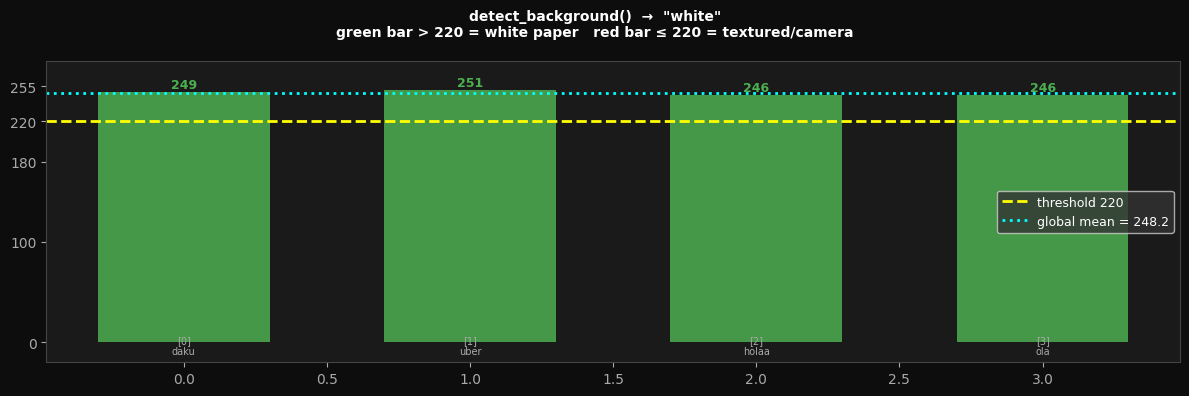

In [20]:
# Corner brightness bars — one per strip
strip_means = []
for arr in strips:
    H2, W2 = arr.shape[:2]
    m2 = max(1, min(H2, W2) // 8)
    strip_means.append(float(np.mean([
        arr[:m2,:m2].mean(), arr[:m2,-m2:].mean(),
        arr[-m2:,:m2].mean(), arr[-m2:,-m2:].mean()
    ])))

fig, ax = plt.subplots(figsize=(3 * N, 4))
ax.set_facecolor('#1a1a1a')

for i, mean in enumerate(strip_means):
    color = '#4CAF50' if mean > 220 else '#e05a2b'
    ax.bar(i, mean, color=color, alpha=0.85, width=0.6)
    ax.text(i, mean + 4, f'{mean:.0f}', ha='center',
            color=color, fontsize=9, fontweight='bold')
    ax.text(i, -12, f'[{i}]\n{os.path.splitext(os.path.basename(paths[i]))[0][:10]}',
            ha='center', color='#aaa', fontsize=7)

ax.axhline(220, color='yellow', linewidth=2, linestyle='--', label='threshold 220')
ax.axhline(global_mean, color='cyan', linewidth=2, linestyle=':',
           label=f'global mean = {global_mean:.1f}')
ax.set_ylim(-20, 280)
ax.set_yticks([0, 100, 180, 220, 255])
ax.tick_params(colors='#aaa')
ax.legend(fontsize=9, labelcolor='white', facecolor='#333')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.suptitle(
    f'detect_background()  →  "{bg_type}"\n'
    'green bar > 220 = white paper   red bar ≤ 220 = textured/camera',
    color='white', fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Step 3 — Build cost matrix

`cost[i, j]` = how well strip `[j]` follows strip `[i]`.  Lower = better match.

In [21]:
def binarize(strip, threshold=None):
    if threshold is None:
        hist, _ = np.histogram(strip.ravel(), bins=256, range=(0,256))
        total   = strip.size 
        best_t, best_var = 155, 0.0
        sum_total = float(np.dot(np.arange(256), hist))
        sum_bg, w_bg = 0.0, 0
        for t in range(256):
            w_bg += hist[t]
            if w_bg == 0: continue
            w_fg = total - w_bg
            if w_fg == 0: break
            sum_bg += t * hist[t]
            mu_bg = sum_bg / w_bg
            mu_fg = (sum_total - sum_bg) / w_fg
            var   = w_bg * w_fg * (mu_bg - mu_fg) ** 2
            if var > best_var: best_var = var; best_t = t
        threshold = best_t
    return np.where(strip < threshold, 0, 255).astype(np.uint8) 

def _ssd(r, l):
    return float(np.sum((r.astype(float) - l.astype(float)) ** 2))

def _xcorr(r, l):
    def norm(p):
        p = p - p.mean(); s = p.std(); return p/s if s>1e-6 else p
    return float(-correlate(norm(r.mean(1)), norm(l.mean(1)), mode='full').max())

def build_cost_matrix(strips, bg_type, ew):
    N2 = len(strips)
    xcorr = (bg_type == 'textured')
    cost  = np.full((N2, N2), np.inf)
    for i in range(N2):
        rr = strips[i][:, -ew:]
        r  = binarize(rr) if xcorr else rr
        for j in range(N2):
            if i == j: continue
            ll = strips[j][:, :ew]
            l  = binarize(ll) if xcorr else ll
            cost[i, j] = _xcorr(r, l) if xcorr else _ssd(r, l)
    return cost


cost   = build_cost_matrix(strips, bg_type, ew)
scores = -cost.copy()
scores[np.isinf(scores)] = float(np.nanmin(scores[np.isfinite(scores)]))
norm   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

print(f'Cost matrix {N}×{N}  built.')
print()
print('Best right-neighbour per strip:')
for i in range(N):
    row = cost[i].copy(); row[i] = np.inf
    b   = int(np.argmin(row))
    stem_i = os.path.splitext(os.path.basename(paths[i]))[0]
    stem_b = os.path.splitext(os.path.basename(paths[b]))[0]
    print(f'  [{i}] "{stem_i}"  →  [{b}] "{stem_b}"') 

Cost matrix 4×4  built.

Best right-neighbour per strip:
  [0] "daku"  →  [3] "ola"
  [1] "uber"  →  [3] "ola"
  [2] "holaa"  →  [3] "ola"
  [3] "ola"  →  [0] "daku"


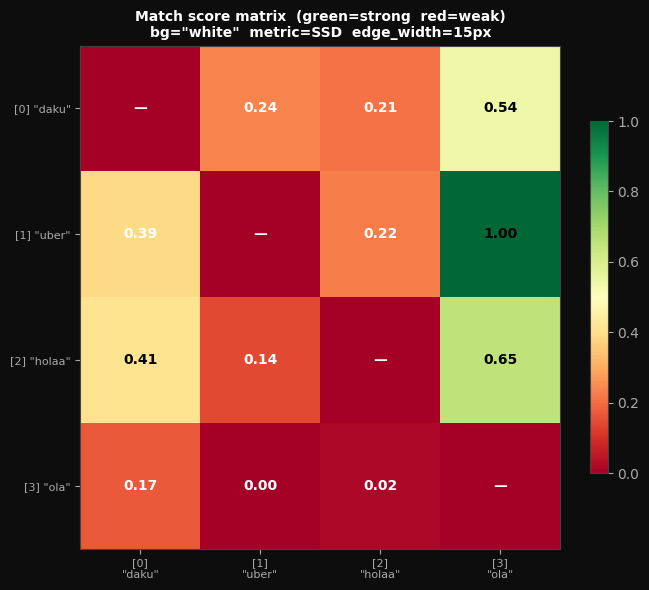

In [22]:
# Score matrix heatmap — axis labels show [index] "name"
stems = [os.path.splitext(os.path.basename(p))[0] for p in paths]

fig, ax = plt.subplots(figsize=(N + 3, N + 2))
im = ax.imshow(norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_title(
    f'Match score matrix  (green=strong  red=weak)\n'
    f'bg="{bg_type}"  '
    f'metric={"SSD" if bg_type=="white" else "XCorr+Otsu"}  '
    f'edge_width={ew}px',
    color='white', fontsize=10, fontweight='bold'
)
xlabels = [f'[{i}]\n"{stems[i][:8]}"' for i in range(N)]
ylabels = [f'[{i}] "{stems[i][:8]}"' for i in range(N)]
ax.set_xticks(range(N)); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_yticks(range(N)); ax.set_yticklabels(ylabels, fontsize=8)
ax.tick_params(colors='#aaa')
for i in range(N):
    for j in range(N):
        v   = '—' if np.isinf(cost[i,j]) else f'{norm[i,j]:.2f}'
        clr = 'black' if norm[i,j] > 0.4 else 'white'
        ax.text(j, i, v, ha='center', va='center',
                fontsize=10, color=clr, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

---
## Step 4 — Find leftmost strip

In [23]:
def find_leftmost(strips):
    return int(np.argmin(
        [float(s[:, :8].astype(float).var()) for s in strips]
    ))


variances = [float(s[:, :8].astype(float).var()) for s in strips]
start     = find_leftmost(strips)

print('Left-edge variance (first 8 columns):')
for i, v in enumerate(variances):
    stem   = os.path.splitext(os.path.basename(paths[i]))[0]
    marker = '  ← LEFTMOST (min variance)' if i == start else ''
    print(f'  [{i}] "{stem}" : {v:.1f}{marker}') 

Left-edge variance (first 8 columns):
  [0] "daku" : 7231.7
  [1] "uber" : 9116.2
  [2] "holaa" : 9087.1
  [3] "ola" : 0.0  ← LEFTMOST (min variance)


---
## Step 5 — Beam search

In [24]:
def beam_search(cost, start, width=5):
    N2    = len(cost)
    start = int(start)
    beams = [(0.0, start, [start], {start})]
    for _ in range(N2 - 1):
        cands = []
        for cum, cur, path, used in beams:
            row = cost[cur].copy()
            for u in used: row[u] = np.inf
            for nxt in [int(x) for x in np.argsort(row)[:width]]:
                if np.isinf(row[nxt]): continue
                cands.append((cum+row[nxt], nxt, path+[nxt], used|{nxt}))
        cands.sort(key=lambda x: x[0])
        beams = cands[:width]
    best = beams[0][2]
    used = set(best)
    while len(best) < N2:
        row = cost[best[-1]].copy()
        for u in used: row[u] = np.inf
        nxt = int(np.argmin(row)); best.append(nxt); used.add(nxt)
    return best


predicted = beam_search(cost, start, BEAM_WIDTH)

print(f'Predicted order : {predicted}')
print()
print('Reading sequence (left → right):')
print(f'  pos 0  [{start}] "{os.path.splitext(os.path.basename(paths[start]))[0]}"  (start)')
for pos in range(1, N):
    idx   = predicted[pos]
    prev  = predicted[pos-1]
    sc    = norm[prev, idx]
    conf  = 'strong' if sc>0.7 else 'moderate' if sc>0.4 else 'WEAK — check this join'
    stem  = os.path.splitext(os.path.basename(paths[idx]))[0]
    print(f'  pos {pos}  [{idx}] "{stem}"  score={sc:.2f}  ({conf})') 

Predicted order : [3, 2, 0, 1]

Reading sequence (left → right):
  pos 0  [3] "ola"  (start)
  pos 1  [2] "holaa"  score=0.02  (WEAK — check this join)
  pos 2  [0] "daku"  score=0.41  (moderate)
  pos 3  [1] "uber"  score=0.24  (WEAK — check this join)


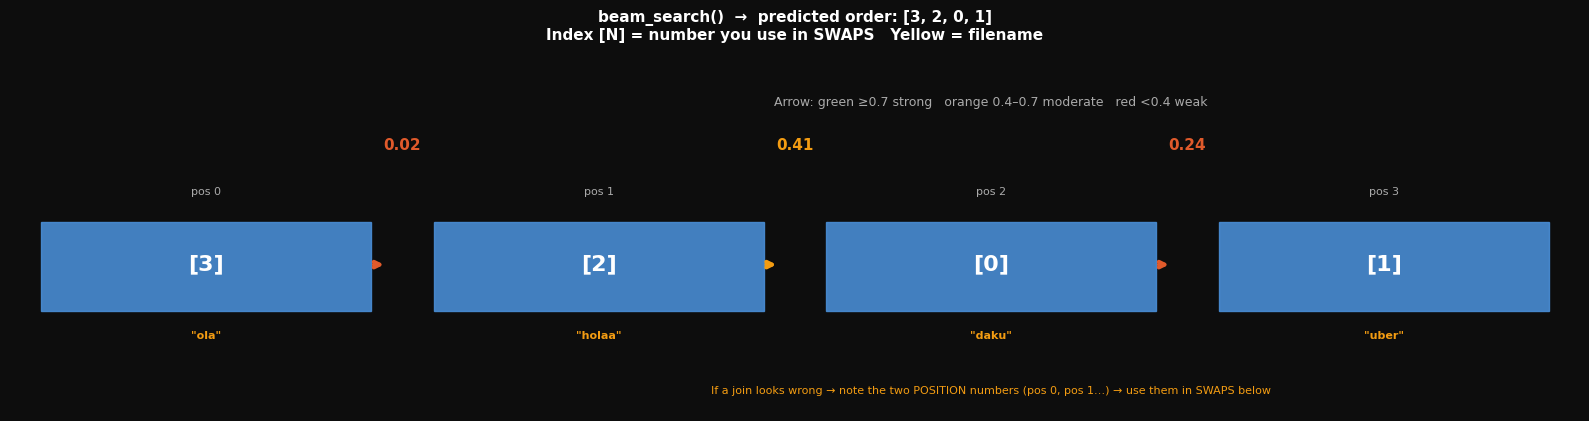

In [25]:
# Chain diagram — shows index AND filename stem
fig, ax = plt.subplots(figsize=(4 * N, 4))
ax.set_facecolor('#111'); ax.axis('off')
ax.set_xlim(-0.5, N - 0.5); ax.set_ylim(-0.4, 2.5)

for pos, idx in enumerate(predicted):
    stem = os.path.splitext(os.path.basename(paths[idx]))[0]
    ax.add_patch(plt.Rectangle((pos-.42, .5), .84, .8,
                               color='#4a90d9', alpha=0.88, zorder=2))
    # index number (large)
    ax.text(pos, .92, f'[{idx}]',
            ha='center', va='center',
            color='white', fontsize=16, fontweight='bold', zorder=3)
    # filename stem (below box)
    ax.text(pos, .25, f'"{stem}"',
            ha='center', color='#f39c12', fontsize=8, fontweight='bold')
    # position label (above box)
    ax.text(pos, 1.55, f'pos {pos}',
            ha='center', color='#aaa', fontsize=8)

    if pos < N - 1:
        jj  = predicted[pos+1]
        sc  = norm[idx, jj]
        col = '#4CAF50' if sc>0.7 else '#f39c12' if sc>0.4 else '#e05a2b'
        ax.annotate('', xy=(pos+.46,.92), xytext=(pos+.42,.92),
                    arrowprops=dict(arrowstyle='->', color=col, lw=3))
        ax.text(pos+.5, 1.95, f'{sc:.2f}',
                ha='center', color=col, fontsize=11, fontweight='bold')

ax.text(N/2, 2.35,
        'Arrow: green ≥0.7 strong   orange 0.4–0.7 moderate   red <0.4 weak',
        ha='center', color='#aaa', fontsize=9)
ax.text(N/2, -0.25,
        'If a join looks wrong → note the two POSITION numbers (pos 0, pos 1…) → use them in SWAPS below',
        ha='center', color='#f39c12', fontsize=8)

plt.suptitle(
    f'beam_search()  →  predicted order: {predicted}\n'
    'Index [N] = number you use in SWAPS   Yellow = filename',
    color='white', fontsize=11, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.show()

---
## Step 6 — Manual correction (SWAPS)

Look at the chain diagram above.  
If two strips are in the wrong position, swap them here.

### What number to put in SWAPS

Use the **position number** (the `pos 0`, `pos 1` labels above the boxes), NOT the index number in brackets.

```
Chain shows:
  pos 0  [3] "joker"  →  pos 1  [0] "ball"  →  pos 2  [1] "tiger"  →  pos 3  [2] "sun"

You think "tiger" and "sun" are swapped (positions 2 and 3):
  SWAPS = [(2, 3)]

After swap:
  pos 0  [3] "joker"  →  pos 1  [0] "ball"  →  pos 2  [2] "sun"  →  pos 3  [1] "tiger"
```

In [26]:
# # ── EDIT THIS CELL ────────────────────────────────────────────────
# #
# # SWAPS = list of (position_a, position_b) pairs
# # Use POSITION numbers from the chain diagram (pos 0, pos 1, ...)
# #
# # Examples:
# #   SWAPS = [(2, 3)]          ← swap positions 2 and 3
# #   SWAPS = [(1, 2), (3, 4)]  ← two separate swaps
# #   SWAPS = []                ← no correction, use algorithm result as-is

# SWAPS = []    # ← edit here

# # ─────────────────────────────────────────────────────────────────

# def apply_swaps(order, swaps):
#     corrected = order.copy()
#     for a, b in swaps:
#         corrected[a], corrected[b] = corrected[b], corrected[a]
#     return corrected


# final_order = apply_swaps(predicted, SWAPS)

# # ── Summary printout ──────────────────────────────────────────────
# print('─' * 55)
# print('  BEFORE / AFTER SWAPS')
# print('─' * 55)
# print(f'  Algorithm predicted : {predicted}')
# if SWAPS:
#     print(f'  Swaps applied       : {SWAPS}')
#     print()
#     for a, b in SWAPS:
#         sa = os.path.splitext(os.path.basename(paths[predicted[a]]))[0]
#         sb = os.path.splitext(os.path.basename(paths[predicted[b]]))[0]
#         print(f'  Swapped: pos {a} [{predicted[a]}] "{sa}"'
#               f'  ↔  pos {b} [{predicted[b]}] "{sb}"')
#     print()
#     print(f'  Final order         : {final_order}')
# else:
#     print('  No swaps — using algorithm result as-is.')
#     print(f'  Final order         : {final_order}')
# print('─' * 55)
# print()
# print('Final reading sequence:')
# for pos, idx in enumerate(final_order):
#     stem = os.path.splitext(os.path.basename(paths[idx]))[0]
#     print(f'  pos {pos} → [{idx}] "{stem}"  ({os.path.basename(paths[idx])})') 

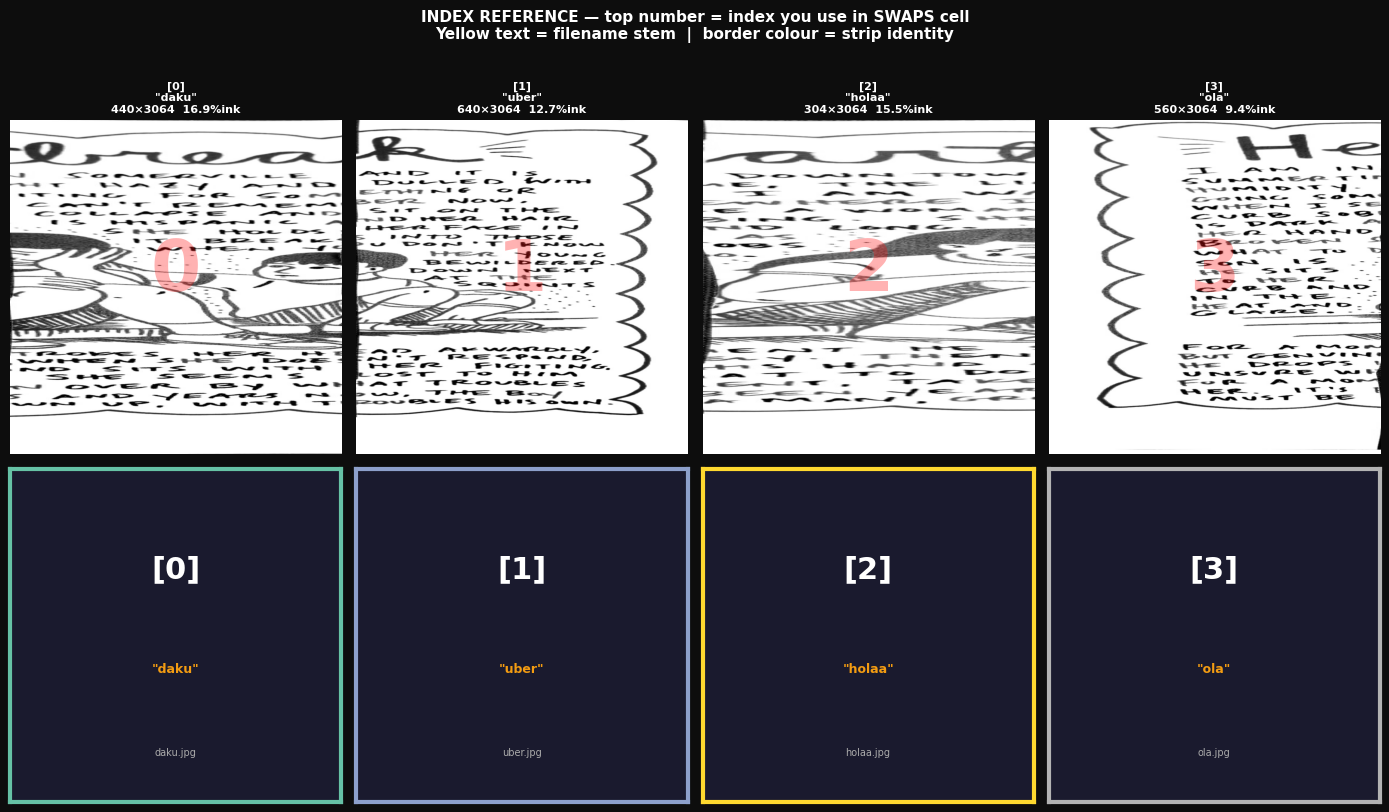

Keep this cell output visible — you will need the index numbers in Step 6.


In [27]:
# Visual index card for each strip
# Large index number + filename so you can identify strips at a glance
fig, axes = plt.subplots(2, N, figsize=(3.5 * N, 8))
if N == 1:
    axes = axes.reshape(2, 1)

COLORS = plt.cm.Set2(np.linspace(0, 1, N))

for i, (s, p) in enumerate(zip(strips, paths)):
    fname = os.path.basename(p)
    stem  = os.path.splitext(fname)[0]   # filename without extension
    ink   = round(np.sum(s < 128) / s.size * 100, 1)

    # top: strip image with large index overlay
    axes[0, i].imshow(s, cmap='gray', aspect='auto', vmin=0, vmax=255)
    for sp in axes[0, i].spines.values():
        sp.set_edgecolor(COLORS[i]); sp.set_linewidth(4)
    # large index number
    axes[0, i].text(
        s.shape[1] * 0.5, s.shape[0] * 0.45,
        str(i),
        ha='center', va='center',
        color='red', fontsize=52, fontweight='bold', alpha=0.30
    )
    axes[0, i].set_title(
        f'[{i}]\n"{stem}"\n{s.shape[1]}×{s.shape[0]}  {ink}%ink',
        color='white', fontsize=8, fontweight='bold'
    )
    axes[0, i].axis('off')

    # bottom: index card (name + stats on dark background)
    axes[1, i].set_facecolor(COLORS[i] * np.array([0.3, 0.3, 0.3, 1]) + np.array([0.1,0.1,0.1,0]))
    axes[1, i].set_facecolor('#1a1a2e')
    axes[1, i].text(0.5, 0.70, f'[{i}]',
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='white', fontsize=22, fontweight='bold')
    axes[1, i].text(0.5, 0.40, f'"{stem}"',
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='#f39c12', fontsize=9, fontweight='bold')
    axes[1, i].text(0.5, 0.15, fname,
                    ha='center', va='center', transform=axes[1, i].transAxes,
                    color='#aaaaaa', fontsize=7)
    for sp in axes[1, i].spines.values():
        sp.set_edgecolor(COLORS[i]); sp.set_linewidth(3)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

plt.suptitle(
    'INDEX REFERENCE — top number = index you use in SWAPS cell\n'
    'Yellow text = filename stem  |  border colour = strip identity',
    color='white', fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()
print('Keep this cell output visible — you will need the index numbers in Step 6.')

In [28]:
#print(final_order)
print(predicted)

[3, 2, 0, 1]


In [29]:
# Reconstruct both versions and show side by side
def reconstruct(strips, order, gap=0):
    H       = max(s.shape[0] for s in strips)
    total_w = sum(strips[i].shape[1] for i in order) + gap * max(0, len(order)-1)
    canvas  = np.ones((H, total_w), dtype=np.uint8) * 255
    x = 0
    for idx in order:
        s, sw = strips[idx], strips[idx].shape[1]
        canvas[:s.shape[0], x:x+sw] = s
        if gap > 0 and x+sw < total_w:
            canvas[:, x+sw:x+sw+gap] = 185
        x += sw + gap
    return canvas


algo_img  = reconstruct(strips, predicted,   gap=8)
final_img = reconstruct(strips, final_order, gap=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].imshow(algo_img, cmap='gray', aspect='auto', vmin=0, vmax=255)
axes[0].set_title(
    f'Algorithm output (gaps show boundaries)\n'
    f'order: {predicted}',
    color='white', fontsize=10, fontweight='bold'
)
# red outlines on swapped positions
for a, b in SWAPS:
    for pos in [a, b]:
        x_s = sum(strips[predicted[k]].shape[1] for k in range(pos)) + pos * 8
        w_s = strips[predicted[pos]].shape[1]
        axes[0].add_patch(mpatches.Rectangle(
            (x_s, 0), w_s, algo_img.shape[0],
            linewidth=3, edgecolor='red', facecolor='none'
        ))
        stem = os.path.splitext(os.path.basename(paths[predicted[pos]]))[0]
        axes[0].text(x_s + w_s//2, 30, f'[{predicted[pos]}]\n"{stem}"',
                     ha='center', color='red', fontsize=8, fontweight='bold')
axes[0].axis('off')

t_color = '#4CAF50' if SWAPS else 'white'
axes[1].imshow(final_img, cmap='gray', aspect='auto', vmin=0, vmax=255)
axes[1].set_title(
    f'Final reconstruction\norder: {final_order}\n'
    'Verify: text reads left → right?',
    color=t_color, fontsize=10, fontweight='bold'
)
axes[1].axis('off')

caption = (f'Swaps applied: {SWAPS}  |  red outlines show swapped positions'
           if SWAPS else 'No swaps applied')
plt.suptitle(caption, color='white', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'final_order' is not defined

---
## Step 7 — Save output

In [ ]:
# Save clean image
Image.fromarray(final_img).save(CLEAN_PATH)
print(f'Saved: {CLEAN_PATH}  ({final_img.shape[1]}×{final_img.shape[0]}px)')

# Save annotated figure
fig2 = plt.figure(figsize=(24, 14))
fig2.patch.set_facecolor('#0d0d0d')
gs   = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.4, wspace=0.2,
                         height_ratios=[3, 1])

def show(ax, img, title, sub=None):
    ax.imshow(img, cmap='gray', aspect='auto', vmin=0, vmax=255)
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=5)
    if sub:
        ax.text(0.5,-0.03,sub,transform=ax.transAxes,
                ha='center',color='#aaa',fontsize=8)
    ax.axis('off')

show(fig2.add_subplot(gs[0,0]),
     reconstruct(strips, list(range(N)), gap=8),
     'Loaded order',
     '  '.join(f'[{i}]"{stems[i][:6]}"' for i in range(N)))
show(fig2.add_subplot(gs[0,1]),
     final_img,
     'Final reconstruction',
     str(final_order))

ax_m = fig2.add_subplot(gs[0,2])
im   = ax_m.imshow(norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax_m.set_title('Score matrix  (cyan=final path)',
               color='white', fontsize=9, fontweight='bold')
ax_m.set_xticks(range(N))
ax_m.set_xticklabels([f'[{i}]\n"{stems[i][:6]}"' for i in range(N)], fontsize=7)
ax_m.set_yticks(range(N))
ax_m.set_yticklabels([f'[{i}] "{stems[i][:6]}"' for i in range(N)], fontsize=7)
ax_m.tick_params(colors='#aaa')
for i in range(N):
    for j in range(N):
        v   = '—' if np.isinf(cost[i,j]) else f'{norm[i,j]:.2f}'
        clr = 'black' if norm[i,j]>0.4 else 'white'
        ax_m.text(j,i,v,ha='center',va='center',fontsize=9,color=clr,fontweight='bold')
for k in range(len(final_order)-1):
    ii,jj = final_order[k], final_order[k+1]
    ax_m.add_patch(plt.Rectangle((jj-.45,ii-.45),.9,.9,
                                  fill=False,edgecolor='cyan',lw=2))
plt.colorbar(im, ax=ax_m, shrink=0.8)

ax_c = fig2.add_subplot(gs[1,:])
ax_c.set_facecolor('#111'); ax_c.axis('off')
ax_c.set_xlim(-0.5,N-0.5); ax_c.set_ylim(-0.5,2.5)
for pos, idx in enumerate(final_order):
    stem = os.path.splitext(os.path.basename(paths[idx]))[0]
    ax_c.add_patch(plt.Rectangle((pos-.40,.4),.80,.8,
                                  color='#4a90d9',alpha=0.88,zorder=2))
    ax_c.text(pos,.8,f'[{idx}]',ha='center',va='center',
              color='white',fontsize=14,fontweight='bold',zorder=3)
    ax_c.text(pos,.12,f'"{stem}"',ha='center',color='#f39c12',fontsize=7,fontweight='bold')
    ax_c.text(pos,1.55,f'pos {pos}',ha='center',color='#aaa',fontsize=8)
    if pos<N-1:
        jj=final_order[pos+1]; sc=norm[idx,jj]
        col='#4CAF50' if sc>0.7 else '#f39c12' if sc>0.4 else '#e05a2b'
        ax_c.annotate('',xy=(pos+.44,.8),xytext=(pos+.40,.8),
                      arrowprops=dict(arrowstyle='->',color=col,lw=2.5))
        ax_c.text(pos+.5,2.05,f'{sc:.2f}',ha='center',color=col,fontsize=10,fontweight='bold')

plt.suptitle(
    'Shredded Document Reconstruction — Real-World Scans (any filenames)\n'
    f'Final order: {final_order}'
    + (f'  |  Swaps: {SWAPS}' if SWAPS else '  |  No manual swaps'),
    color='white', fontsize=11, fontweight='bold', y=1.01
)
fig2.savefig(RESULT_PATH, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.close(fig2)

print(f'Saved: {RESULT_PATH}')
print()
print('Final reading order:')
for pos, idx in enumerate(final_order):
    stem = os.path.splitext(os.path.basename(paths[idx]))[0]
    print(f'  pos {pos} → [{idx}] "{stem}"')